# Visualization of spectrum

In [1]:
import os, sys
os.environ["MPICH_GPU_SUPPORT_ENABLED"] = "0"
import glob
import random
import fitsio
import numpy as np
from astropy.table import Table,join,unique,vstack
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.cm import get_cmap
from matplotlib import ticker
# from mockfactory import Catalog
import random

from desitarget.targetmask import desi_mask, bgs_mask
from desitarget.sv3.sv3_targetmask import desi_mask as sv3_desi_mask
from desitarget.sv3.sv3_targetmask import bgs_mask as sv3_bgs_mask
from desitarget.targetmask import zwarn_mask as zmtl_zwarn_mask

from LSS.globals import main
import LSS.common_tools as common
from prospect import viewer, utilities

sys.path.append('../../')
from helper import REDSHIFT_BIN_GLOBAL, CSPEED
from dv_tools import get_cthr, get_repeats_dv
from plotting_tools import COLOR_OVERALL, CONF_TOL_TRACER, get_spec_lines, plot_confusion_lines, plot_sky_residuals, plot_conf_dots
from plotting_tools import get_spec_lines, plot_confusion_lines, plot_sky_residuals, plot_conf_dots

%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
# fn = '/dvs_ro/cfs/projectdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v1/LRG_full.dat.fits'
fn = '/dvs_ro/cfs/projectdirs/desi/survey/catalogs/DA2/LSS/loa-v1/datcomb_dark_spec_zdone.fits'
data = Table.read(fn)
data
# targetids = data['TARGETID']
# data["TARGETID"]

TARGETID,LASTNIGHT,Z,ZERR,ZWARN,CHI2,COEFF,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,LOCATION,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,FIBERASSIGN_X,FIBERASSIGN_Y,PRIORITY,DESI_TARGET,BGS_TARGET,TILEID,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,TSNR2_BGS_B,TSNR2_ELG_B,TSNR2_LRG_B,TSNR2_LYA_B,TSNR2_QSO_B,TSNR2_BGS_R,TSNR2_ELG_R,TSNR2_LRG_R,TSNR2_LYA_R,TSNR2_QSO_R,TSNR2_BGS_Z,TSNR2_ELG_Z,TSNR2_LRG_Z,TSNR2_LYA_Z,TSNR2_QSO_Z,TSNR2_BGS,TSNR2_ELG,TSNR2_LRG,TSNR2_LYA,TSNR2_QSO,ZWARN_MTL,Z_QN,Z_QN_CONF,IS_QSO_QN
int64,int32,float64,float64,int64,float64,float64[10],int64,bytes6,bytes20,int64,float64,int64,int32,int32,float64,float64,float32,float32,int32,int64,int64,int32,int16,float32,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,float64,float64,int16
2204596575404032,20211207,0.9202842403601226,8.215467697228755e-05,4,8223.923013165593,29.30920067586368 .. -4.57347297118279,7929,GALAXY,--,10,6.247507736086845,7231,3696,0,18.56004,-8.77222,-254.96051,88.29371,1900,4611686018427387904,0,5843,2,2468.498,1,0.005,0.005,0.01,0.01,0.79253864,900.5411,0.17313677,1.650976,128.54546,4.1313586,2628.6523,29.44368,42.835995,0.051519416,7.7262945,5251.0786,120.117035,56.207726,0.0,21.933668,8780.271,149.73386,100.694695,128.59697,33.79132,4,2.1043300258932427,0.0011781915615822337,0
2204623473475584,20240109,0.18525533312667702,6.52643938379786e-05,4,7819.787999313325,52.18568788884605 .. 9.090520212028471,7834,GALAXY,--,10,0.6904128678143024,187,29,0,197.32561,-7.66477,23.872591,-230.68741,1900,4611686018427387904,0,6271,1,1524.9349,1,0.00048634337,0.00048634337,7.197817e-05,7.197817e-05,0.7914992,593.60474,0.11570977,1.0609982,99.1876,3.0659184,2339.8188,24.704765,35.978054,0.045081645,7.463185,3583.5293,85.996994,38.85174,0.0,17.17564,6516.953,110.81747,75.89079,99.23268,27.704742,4,0.9887578312190795,7.508927148918077e-05,0
2204652607111168,20220309,0.016411489188294572,3.191587475369417e-05,0,8329.16237297532,14.255310696681702 .. -7.589409623906783,7928,GALAXY,--,10,24.80390017834725,7423,3771,0,145.31148,-6.51893,-334.29965,163.5737,1900,4611686018427387904,0,10367,3,3423.7017,1,-0.00010566958,0.00010566958,0.00013583424,0.00013583424,0.79230446,609.81744,0.10840748,1.1401714,76.68697,2.533789,2312.7585,25.286236,36.877457,0.04271267,6.4581203,5133.349,121.85589,55.616283,0.0,21.301836,8055.925,147.25053,93.63391,76.72968,30.293745,0,1.7035186598092165,0.010176743245881605,0
2204698811564032,20221027,1.4071094922636993,0.00012600868959775256,4,8154.094831064343,-19.67989051370529 .. -10.817207187325018,7929,GALAXY,--,10,0.7681537866592407,5227,2599,0,30.11329,-4.56223,45.66787,280.2263,1900,4611686018427387904,0,9492,3,2649.941,2,0.0018456026,0.0031668087,0.00288169,0.0034024345,0.7920149,684.50665,0.12730375,1.309056,89.958725,3.1949205,2505.9265,25.65557,37.840946,0.05787656,7.416236,4599.932,102.472664,48.270966,0.0,19.950916,7790.365,128.25554,87.42097,90.0166,30.562073,4,1.590997353036471,0.002710550342419712,0
2204712820539392,20220301,0.016040149651302335,2.3910465384871773e-05,0,8094.776546521345,94.03003216328977 .. 12.724819131875243,7929,GALAXY,--,10,22.177696721395478,3425,1767,0,146.92907,-3.97609,355.18756,89.85914,1900,4611686018427387904,0,2558,2,2263.646,1,0.0026061225,0.0026061225,-0.0008273111,0.0008273111,0.7923421,557.44336,0.098525204,1.118958,55.269707,2.2096505,1933.3313,23.357107,33.623802,0.03879282,5.5580626,4206.3125,89.82893,44.136856,0.0,15.813518,6697.087,113.28457,78.879616,55.3085,23.58123,0,1.6467931095079722,0.048941458323948105,0
2204728519819264,20211008,0.4540019230769707,6.778581023548571e-05,4,7736.540875785053,12.09081202254663 .. -5.372964996649557,7762,GALAXY,--,10,4.886444889008999,7087,3979,0,3.91221999,-3.1253,-159.86632,31.645496,1900,46116860184273879

In [32]:
def identify_sky_residuals(d, skyZ_list, tol=1e-3, cols = ['Z1', 'Z2']):
    """
    Identify potential sky-residual-driven failures by matching Z1 and/or Z2
    to a set of known sky redshift spikes.
    """
    skyZ = np.asarray(list(skyZ_list), dtype=float)
    if skyZ.size == 0: return {}
    targetid = np.asarray(d["TARGETID"])
    # Load requested z columns
    zcols = {col: np.asarray(d[col], dtype=float) for col in cols}
    tile1 = np.asarray(d["TILEID_1"])
    tile2 = np.asarray(d["TILEID_2"])
    sky_dict = {}
    for zsky in skyZ:
        key = f"sky z≈{zsky:g}"
        # Match if ANY requested column is close
        m = np.zeros(len(targetid), dtype=bool)
        for col, z in zcols.items():
            m |= (np.abs(z - zsky) < tol)
        if np.any(m):
            sky_dict[key] = [
                {"TARGETID": int(t), 
                "TILEID_1": int(tile1[i]),
                "TILEID_2": int(tile2[i]),
                 **{col: float(zcols[col][i]) for col in cols}}
                for i, t in enumerate(targetid) if m[i]]
        else:
            sky_dict[key] = []
    return sky_dict

In [9]:
survey = 'DA2'
time = 'bright'

mainp = main('BGS', 'loa-v1')#get settings for bright time

mt = mainp.mtld
tiles = mainp.tiles
imbits = mainp.imbits #mask bits applied to targeting
ebits = mainp.ebits #extra mask bits we think should be applied

tsnrcut = mainp.tsnrcut
dchi2 = mainp.dchi2
tnsrcol = mainp.tsnrcol        
zmin = mainp.zmin
zmax = mainp.zmax
badfib = mainp.badfib

#get set of tiles
wd = mt['SURVEY'] == 'main'
wd &= mt['ZDONE'] == 'true'
wd &= mt['FAPRGRM'] == time
if survey == 'Y1':
    wd &= mt['ZDATE'] < 20220900
if survey == 'DA2':
    wd &= mt['ZDATE'] < 20240410
mtld = mt[wd]

# for tracer
ldirspec = '/global/cfs/cdirs/desi/survey/catalogs/'+f'{survey}'+'/LSS/'+'loa-v1'+'/'
specfo_ = ldirspec+f'datcomb_{time}_spec_zdone.fits'
specf_ = Table(fitsio.read(specfo_.replace('global','dvs_ro')))
sel = np.isin(specf_['TILEID'],mtld['TILEID'])
specf_ = specf_[sel]
specf_ = Table(specf_)
specf_.keep_columns(['TARGETID','Z','ZWARN','ZERR', 'DELTACHI2','LOCATION','BGS_TARGET','TILEID','TSNR2_BGS','TSNR2_ELG','ZWARN_MTL','COADD_FIBERSTATUS','FIBER','LASTNIGHT'])
specf_ = common.cut_specdat(specf_,badfib=mainp.badfib_td,tsnr_min=tsnrcut,tsnr_col=tnsrcol,fibstatusbits=mainp.badfib_status,remove_badfiber_spike_nz=True,mask_petal_nights=True)

BGS
number with no data 86136
number with bad qa 508781
number at low tsnr2 453265
will mask fibers with time dependence
number removed from time dependent mask is 317259
number removed from spike mask is 42775
number removed from petal night mask is 23826


In [10]:
specf_

TARGETID,LASTNIGHT,Z,ZERR,ZWARN,DELTACHI2,LOCATION,FIBER,COADD_FIBERSTATUS,BGS_TARGET,TILEID,TSNR2_BGS,TSNR2_ELG,ZWARN_MTL
int64,int32,float64,float64,int64,float64,int64,int32,int32,int64,int32,float32,float32,int64
2314745960988682,20221011,1.1689003956872004,8.860092117390418e-05,4,0.9188570976257324,396,314,0,0,21248,1805.4302,33.403988,4
2314745960988682,20221124,0.6351545947205817,6.457424997579893e-05,4,6.5049618780612946,7067,3961,0,0,23676,1733.1743,28.348598,4
2314752776732684,20220923,0.17160905081785224,3.9567104728892356e-05,4,1.022256013005972,3407,1979,0,0,25376,1544.118,22.799044,4
2315511140450304,20240219,1.4747840045493785,0.00015242951452185382,4,6.280575767159462,5012,2822,0,0,22736,1552.0608,29.3657,4
2367458732146692,20220212,-8.310010185815913e-05,2.3451113158223144e-05,0,147.10162146538823,7436,3583,0,0,26244,1752.7129,33.74497,0
2368681464037380,20230606,-6.960223860664914e-05,2.0288085358464356e-05,0,109.09337427849005,2081,1274,0,0,22307,1944.2683,41.306778,0
2368681472425988,20230806,1.0063850950102339e-05,3.1109080629077786e-05,0,106.45923391547876,5202,2747,0,0,23876,1100.5427,15.338502,0
2368684874006535,20230601,1.3197541273085525,0.0001140629965337775,4,5.272024169564247,4259,2009,0,0,25444,1940.0203,36.55584,4
2368701667999750,20210629,1.498353411187184,9.75758646519904e-05,0,17.267751913517714,5156,2739,0,0,20746,1867.9817,31.982304,0


In [26]:
IDs = [39627322948592135,39627363390065563,39627374978928802,39627386106421193,39627398022433156,39627415583984806, 
       39627438556191838,39627450426066285,39627467278781852,39627479060582118,39627491693828227,39627508718504046,39627520991042881,39627532605066452,39627543891938387,
       39627564762795445,39627573562446945,39627580030060079,39627587156181598,39627592977876007,39627598745043646,39627606517091667,39627610820446802,39627616642139174,]
TILEIDs = []
for ID in IDs:
    TILEID = specf_[specf_['TARGETID']==ID]['TILEID'].value[0]
    TILEIDs.append(f'{TILEID}')

In [27]:
TILEIDs

['26167',
 '21450',
 '23017',
 '21475',
 '21424',
 '21451',
 '25395',
 '26163',
 '22116',
 '22116',
 '21435',
 '20135',
 '20684',
 '24843',
 '22092',
 '20259',
 '22426',
 '20161',
 '27781',
 '23044',
 '26983',
 '23116',
 '24603',
 '25362']

In [33]:
tracer = 'BGS'
tol = CONF_TOL_TRACER[tracer]
repeat_dir = '/pscratch/sd/s/shengyu/repeats/DA2/loa-v1'
d = Table.read(f'{repeat_dir}/{tracer}repeats_info.fits', hdu=1) 
cthr = get_cthr(tracer)
dv =  (d['Z_2']-d['Z_1'])/(1+d['Z_1'])*CSPEED
sel_z = (d['Z_1']>0.1)&(d['Z_1']<0.4)
d = d[(abs(dv)>cthr)&sel_z]
conf_lines = (identify_sky_residuals(d, skyZ_list=[1.65], tol=0.1, cols = ['Z_1', 'Z_2']))
sky_set = conf_lines['sky z≈1.65']

In [34]:
sky_set

[{'TARGETID': 39627392251071145,
  'TILEID_1': 24562,
  'TILEID_2': 26128,
  'Z_1': 0.14824466651783705,
  'Z_2': 1.6009107010087626},
 {'TARGETID': 39627403269513808,
  'TILEID_1': 20170,
  'TILEID_2': 21732,
  'Z_1': 0.2924219627318538,
  'Z_2': 1.6971062409140545},
 {'TARGETID': 39627403953176793,
  'TILEID_1': 21451,
  'TILEID_2': 23017,
  'Z_1': 0.1713818890599907,
  'Z_2': 1.6687877286037631},
 {'TARGETID': 39627427055404427,
  'TILEID_1': 21443,
  'TILEID_2': 26170,
  'Z_1': 0.19536480035016648,
  'Z_2': 1.6379887140641125},
 {'TARGETID': 39627427298678880,
  'TILEID_1': 21503,
  'TILEID_2': 26144,
  'Z_1': 0.3103332109489755,
  'Z_2': 1.6977238004687571},
 {'TARGETID': 39627438287753652,
  'TILEID_1': 20170,
  'TILEID_2': 21732,
  'Z_1': 0.383380378784603,
  'Z_2': 1.6461625068132824},
 {'TARGETID': 39627468138614479,
  'TILEID_1': 23010,
  'TILEID_2': 27742,
  'Z_1': 0.353019917942285,
  'Z_2': 1.657535032229739},
 {'TARGETID': 39627473956113046,
  'TILEID_1': 23045,
  'TILEID

Text(0, 0.5, 'BGS-$z_2$')

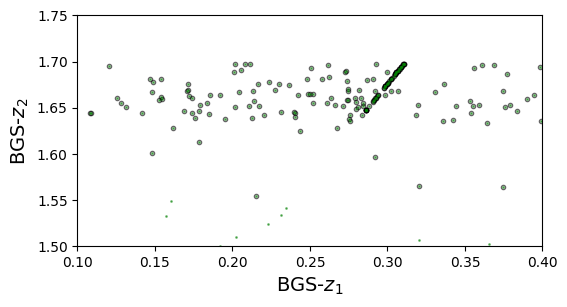

In [35]:
(zmin, zmax) = REDSHIFT_BIN_GLOBAL[tracer]
zrange = np.linspace(zmin, zmax, 10)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(zrange, zrange, color='black', lw=0.8)
tol = CONF_TOL_TRACER[tracer]
# plot_sky_residuals(ax_top, [1.65])
name_set = list(get_spec_lines(tracer).keys())
line_set = list(get_spec_lines(tracer).values())
# plot_confusion_lines(ax_top, line_set, name_set, focus = r'[H$\,\alpha$]', remove = [r"[S$\,\mathrm{II}$]", r"[N$\,\mathrm{II}$]", r"[O$\,\mathrm{II}$]", r"[O$\,\mathrm{III1}$]")
# plot_confusion_lines(ax, line_set, name_set, focus = r'[H$\,\alpha$]', remove = [])
# plot_conf_dots(ax_top, (identify_line_confusions(d, line_set, name_set, focus = r'[H$\,\alpha$]', remove = [r"[S$\,\mathrm{II}$]", r"[N$\,\mathrm{II}$]", r"[O$\,\mathrm{II}$]", r"[O$\,\mathrm{III1}$]"],  tol=tol)))

# ax.plot(0.2914658831400335, 1.658877029057061, "o", alpha=0.6, markersize=4, color = 'red')
plot_conf_dots(ax, conf_lines, cols=['Z_1','Z_2'])
# ax_top.legend(loc='upper center', bbox_to_anchor=(0.5, 1.22), fontsize=11, ncol=2)
# ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.22), fontsize=11, ncol=10)
ax.plot(d["Z_1"],d["Z_2"],'.',markersize=2.,color='green',alpha=0.5)
ax.set_xlim(zrange.min(), zrange.max())
ax.set_ylim(zrange.min()+1.4, 1.75)
ax.set_xlabel(f'{tracer}-'+r'$z_1$', fontsize=14)
ax.set_ylabel(f'{tracer}-'+r'$z_2$', fontsize=14)


In [ ]:
# import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["HDF5_DISABLE_VERSION_CHECK"] = "2"

indx = 2
datadir = '/dvs_ro/cfs/cdirs/desi/spectro/redux'+f'/loa/tiles/cumulative' 
targets = [sky_set[indx]['TARGETID']]
print(targets, sky_set[indx]['Z_1'],sky_set[indx]['Z_2'])
tiles = [f"{sky_set[indx]['TILEID_1']}", f"{sky_set[indx]['TILEID_2']}"]

datadir = '/dvs_ro/cfs/cdirs/desi/spectro/redux'+f'/loa/tiles/cumulative' 
targets = IDs
tiles = TILEIDs
subset_db = utilities.create_subsetdb(datadir, dirtree_type='cumulative', tiles=tiles)
target_db = utilities.create_targetdb(datadir, subset_db, dirtree_type='cumulative')
spectra, zcat, rrcat = utilities.load_spectra_zcat_from_targets(targets, datadir, target_db, dirtree_type='cumulative', with_redrock_details=True)
viewer.plotspectra(spectra, zcatalog=zcat, redrock_cat = rrcat,notebook=True,
                   title='My TARGETIDs', top_metadata=['TARGETID', 'TILEID', 'FIBER', 'TSNR2'], model_from_zcat=False)

petal_loc = tiles // 500
tamplate_path = glob('/global/cfs/cdirs/desi/spectro/redux/loa/tiles/cumulative/tiles/rrmodel')

[39627403953176793] 0.1713818890599907 1.6687877286037631
INFO:spectra.py:453:read_spectra: iotime 0.376 sec to read spectra from:  coadd-5-21451-thru20211115.fits at 2026-02-11T07:46:30.714330
[006521.85]  02-11 07:46  desiutil.log.dlm58.info      INFO     iotime 0.376 sec to read spectra from:  coadd-5-21451-thru20211115.fits at 2026-02-11T07:46:30.714330
INFO:spectra.py:453:read_spectra: iotime 0.344 sec to read spectra from:  coadd-7-23017-thru20221009.fits at 2026-02-11T07:46:31.965675
[006523.10]  02-11 07:46  desiutil.log.dlm58.info      INFO     iotime 0.344 sec to read spectra from:  coadd-7-23017-thru20221009.fits at 2026-02-11T07:46:31.965675
[006524.34]  02-11 07:46  astropy                      WARNING  MergeConflictWarning: Cannot merge meta key 'SPGRPVAL' types <class 'int'> and <class 'int'>, choosing SPGRPVAL=20221009
[006524.35]  02-11 07:46  astropy                      WARNING  MergeConflictWarning: Cannot merge meta key 'TILEID' types <class 'int'> and <class 'int'

TypeError: unsupported operand type(s) for //: 'list' and 'int'